# Классификация пород кошек и собак по лицу



Используемые библиотеки:

In [65]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import seaborn as sn
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.utils import *

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Softmax
from tensorflow.keras.layers import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.metrics import SparseTopKCategoricalAccuracy

from pathlib import Path
set_random_seed(1337)

Используем упрощенный датасет [Oxford-IIIT Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/) с вырезанными лицами домашних животных. Для начала загружаем датасет:

In [2]:
!wget http://www.soshnikov.com/permanent/data/petfaces.tar.gz
!tar xfz petfaces.tar.gz
!rm petfaces.tar.gz

--2024-09-08 08:39:35--  http://www.soshnikov.com/permanent/data/petfaces.tar.gz
Resolving www.soshnikov.com (www.soshnikov.com)... 79.137.227.122
Connecting to www.soshnikov.com (www.soshnikov.com)|79.137.227.122|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24483412 (23M) [application/x-tar]
Saving to: ‘petfaces.tar.gz’

petfaces.tar.gz     100%[===================>]  23.35M   192KB/s    in 2m 6s   

2024-09-08 08:41:42 (189 KB/s) - ‘petfaces.tar.gz’ saved [24483412/24483412]



Создадим необходимые папки для случаев "собаки против кошек" и "породы"

In [7]:
!mkdir petfaces2
!mv petfaces petfaces35
%cd petfaces2/
!mkdir cats
!mkdir dogs
%cd ..
!cp petfaces35/cat_*/*.jpg petfaces2/cats
!cp petfaces35/dog_*/*.jpg petfaces2/dogs

/content/petfaces2
/content


Открываем датасет для двух категорий, разделяем на обучение и тест:

In [46]:
image_size = (256, 256)
batch_size = 32
seed = 1337

train_ds, test_ds = image_dataset_from_directory(
    "petfaces2",
    validation_split=0.2,
    subset="both",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
)

Found 3211 files belonging to 2 classes.
Using 2569 files for training.
Using 642 files for validation.


Строим модель:

In [66]:
model = Sequential()
model.add(Input(shape=(256, 256, 3)))
model.add(Conv2D(8, 3, activation="relu"))
model.add(MaxPooling2D((3,3), strides=(3,3)))
model.add(Conv2D(16, 7, activation="relu"))
model.add(MaxPooling2D((3,3), strides=(3,3)))
# model.add(Dropout(0.1))
model.add(Conv2D(16, 15, activation="relu"))
model.add(MaxPooling2D((3,3), strides=(3,3)))
model.add(Flatten())

# model.add(Dense(6))
model.add(Dense(2))
model.add(Softmax())

Summary:

In [67]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_45 (Conv2D)                   │ (None, 254, 254, 8)         │             224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_45 (MaxPooling2D)      │ (None, 84, 84, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_46 (Conv2D)                   │ (None, 78, 78, 16)          │           6,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_46 (MaxPooling2D)      │ (None, 26, 26, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_47 (Conv2D)                   │ (None, 12, 12, 16)          │          57,616 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_47 (MaxPooling2D)      │ (None, 4, 4, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_15 (Flatten)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 2)                   │             514 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ softmax_15 (Softmax)                 │ (None, 2)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 64,642 (252.51 KB)

 Trainable params: 64,642 (252.51 KB)

 Non-trainable params: 0 (0.00 B)

Обучаем модель:

In [68]:
# Папок с кошками в два раза меньше, чем с собаками.
# В каждой папке около 200 фото конкретного вида.
# Поэтому добавим веса к модели для баланса классов.

class_weights = {
    0: 2,
    1: 1
}
ep = 5
hist = model.fit(train_ds, validation_data=test_ds, epochs=ep, class_weight=class_weights)

Epoch 1/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.5456 - loss: 10.8917 - val_accuracy: 0.6231 - val_loss: 0.6563
Epoch 2/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.7295 - loss: 0.7409 - val_accuracy: 0.7664 - val_loss: 0.5254
Epoch 3/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.8205 - loss: 0.5248 - val_accuracy: 0.7944 - val_loss: 0.4998
Epoch 4/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.8789 - loss: 0.3888 - val_accuracy: 0.7928 - val_loss: 0.5099
Epoch 5/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8888 - loss: 0.3413 - val_accuracy: 0.8396 - val_loss: 0.4557


Результаты:

Confusion matrix:

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


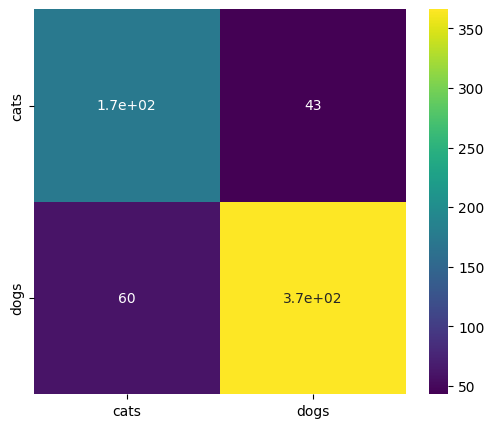

In [69]:
cn = test_ds.class_names
y_real = np.array([])
y_pred = np.array([])

for x, y in test_ds:
    y_real = np.concatenate((y_real, y), axis=None)
    y_pred = np.concatenate((y_pred, np.argmax(model.predict(x), axis=1)), axis=None)

confusion_matrix = tf.math.confusion_matrix(y_real, y_pred, num_classes=2)

df_cm = pd.DataFrame(confusion_matrix, index = [i for i in cn], columns = [i for i in cn])

plt.figure(figsize = (6, 5))
sn.heatmap(df_cm, annot=True, cmap='viridis')
plt.show()

Accuracy и Loss:

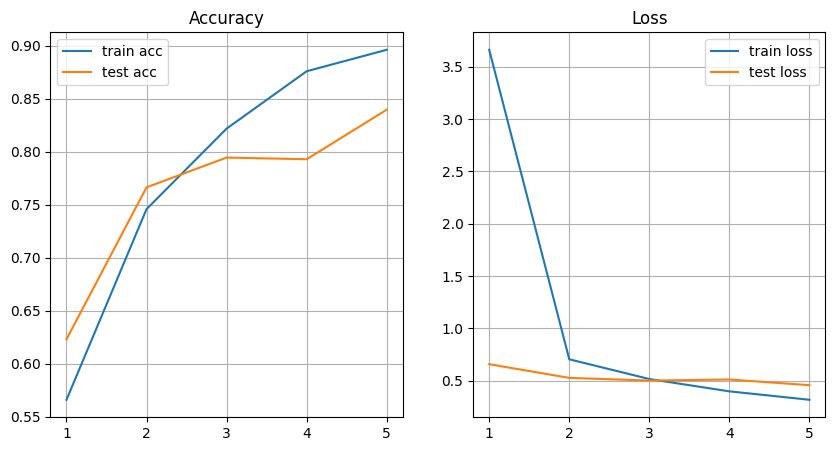

In [70]:
acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, ep + 1), acc, label='train acc')
plt.plot(range(1, ep + 1), val_acc, label='test acc')
plt.legend()
plt.grid()
plt.title('Accuracy')

loss = hist.history['loss']
val_loss = hist.history['val_loss']

plt.subplot(1, 2, 2)
plt.plot(range(1, ep + 1), loss, label='train loss')
plt.plot(range(1, ep + 1), val_loss, label='test loss')
plt.legend()
plt.grid()
plt.title('Loss')

plt.show()

Задача для видов кошек и собак:

Добавим датасет:

In [71]:
image_size = (256, 256)
batch_size = 32
seed = 1337

train_ds35, test_ds35 = image_dataset_from_directory(
    "petfaces35",
    validation_split=0.2,
    subset="both",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
)

Found 3211 files belonging to 35 classes.
Using 2569 files for training.
Using 642 files for validation.


Строим модель

In [89]:
model35 = Sequential()
model35.add(Input(shape=(256, 256, 3)))
model35.add(RandomFlip("horizontal"))
model35.add(RandomRotation(0.1),)
model35.add(RandomZoom(0.1),)
model35.add(Conv2D(16, 3, activation='relu'))
model35.add(MaxPooling2D((3, 3), strides=(3,3)))
model35.add(Conv2D(32, 3, activation='relu'))
model35.add(MaxPooling2D((3, 3), strides=(2,2)))
model35.add(Conv2D(64, 3, activation='relu'))
model35.add(MaxPooling2D(3))
model35.add(Flatten())
model35.add(Dropout(0.2))
model35.add(Dense(35))
model35.add(Softmax())

Summary

In [90]:
top3_accuracy = SparseTopKCategoricalAccuracy(k=3, name='top3_accuracy')
model35.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy", top3_accuracy])
model35.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation_1 (RandomRotation)   │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom_1 (RandomZoom)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_60 (Conv2D)                   │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_60 (MaxPooling2D)      │ (None, 84, 84, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_61 (Conv2D)                   │ (None, 82, 82, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_61 (MaxPooling2D)      │ (None, 40, 40, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_62 (Conv2D)                   │ (None, 38, 38, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_62 (MaxPooling2D)      │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_20 (Flatten)                 │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 35)                  │         322,595 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ softmax_20 (Softmax)                 │ (None, 35)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 346,179 (1.32 MB)

 Trainable params: 346,179 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Обучаем модель:

In [91]:
ep35 = 15
hist35 = model35.fit(train_ds35, validation_data=test_ds35, epochs=ep35)

Epoch 1/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.0517 - loss: 16.5410 - top3_accuracy: 0.1562 - val_accuracy: 0.1293 - val_loss: 3.1622 - val_top3_accuracy: 0.3069
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.1699 - loss: 3.0527 - top3_accuracy: 0.3380 - val_accuracy: 0.2368 - val_loss: 2.8930 - val_top3_accuracy: 0.4299
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.2589 - loss: 2.7524 - top3_accuracy: 0.4653 - val_accuracy: 0.2960 - val_loss: 2.8007 - val_top3_accuracy: 0.5062
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.2772 - loss: 2.6222 - top3_accuracy: 0.5114 - val_accuracy: 0.3146 - val_loss: 2.4302 - val_top3_accuracy: 0.5717
Epoch 5/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.3461 - loss: 2.2912 - top3_accuracy: 0.5944 - val_accuracy: 0.4174 - val_loss: 2.1131 - val_top3_accuracy: 0.6589
Epoch 6/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.4159 - loss: 2.0339 - top3_accuracy: 0.

Результаты:

Accuracy и Loss:

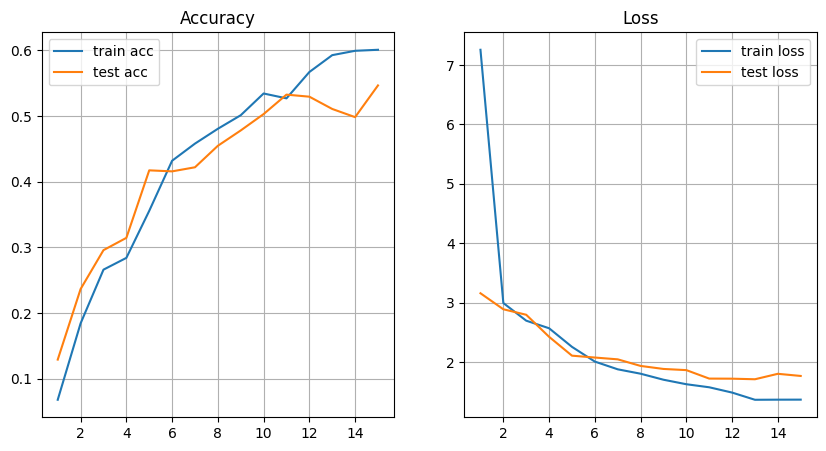

In [92]:
acc35 = hist35.history['accuracy']
val_acc35 = hist35.history['val_accuracy']

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, ep35 + 1), acc35, label='train acc')
plt.plot(range(1, ep35 + 1), val_acc35, label='test acc')
plt.legend()
plt.grid()
plt.title('Accuracy')

loss35 = hist35.history['loss']
val_loss35 = hist35.history['val_loss']

plt.subplot(1, 2, 2)
plt.plot(range(1, ep35 + 1), loss35, label='train loss')
plt.plot(range(1, ep35 + 1), val_loss35, label='test loss')
plt.legend()
plt.grid()
plt.title('Loss')

plt.show()

Confusion matrix:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 609ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 733ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


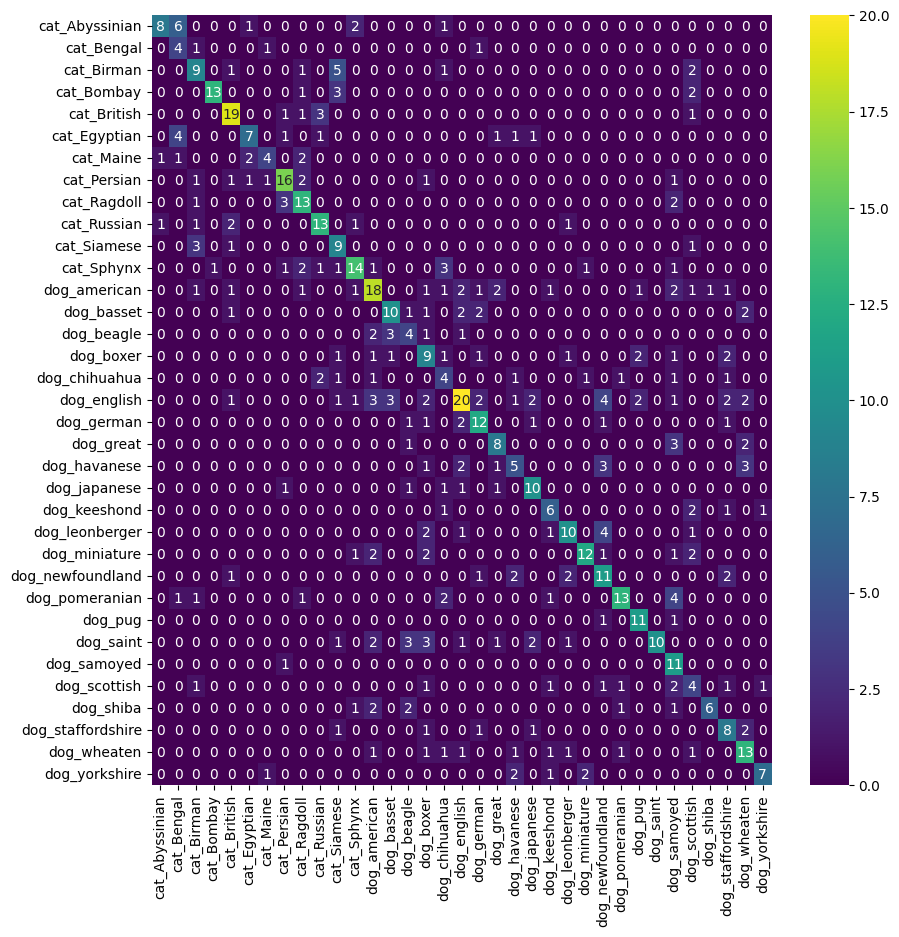

In [93]:
cn = test_ds35.class_names
y_real = np.array([])
y_pred = np.array([])

for x, y in test_ds35:
    y_real = np.concatenate((y_real, y), axis=None)
    y_pred = np.concatenate((y_pred, np.argmax(model35.predict(x), axis=1)), axis=None)

confusion_matrix = tf.math.confusion_matrix(y_real, y_pred, num_classes=35)

df_cm = pd.DataFrame(confusion_matrix, index = [i for i in cn], columns = [i for i in cn])

plt.figure(figsize = (10, 10))
sn.heatmap(df_cm, annot=True, cmap='viridis')
plt.show()

Top-3 accuracy:

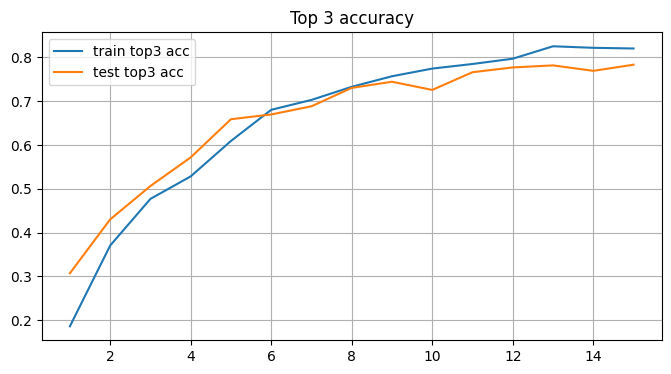

In [95]:
top3_acc = hist35.history['top3_accuracy']
val_top3_acc = hist35.history['val_top3_accuracy']

plt.figure(figsize=(8, 4))
plt.subplot(1, 1, 1)
plt.plot(range(1, ep35 + 1), top3_acc, label='train top3 acc')
plt.plot(range(1, ep35 + 1), val_top3_acc, label='test top3 acc')
plt.legend()
plt.grid()
plt.title('Top 3 accuracy')

plt.show()